In [1]:
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

# Check that keys loaded properly
print("Tavily Key loaded:", os.getenv("TAVILY_API_KEY") is not None)
print("Groq Key loaded:", os.getenv("GROQ_API_KEY") is not None)

from langchain_groq import ChatGroq
model = ChatGroq(model="qwen/qwen3.8-27b")

Tavily Key loaded: True
Groq Key loaded: True


In [2]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=5,
    topic="general"
)

tavily_search_tool.invoke("What is the current AI news")

{'query': 'What is the current AI news',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.artificialintelligence-news.com',
   'title': 'AI News | Latest News | Insights Powering AI-Driven Business ...',
   'content': 'October 30, 2025\n\n### Malaysia launches Ryt Bank, its first AI-powered bank\n\nFinance AI\n\nAugust 26, 2025\n\n### Google’s Veo 3 AI video creation tools are now widely available\n\nAI in Action\n\nJuly 29, 2025\n\n#### Computer Vision\n\n### Microsoft’s Majorana 2 quantum chip is also a case study for agentic AI in R&D\n\nInside AI\n\nJune 3, 2026\n\n### US and Japan announce sweeping AI and tech collaboration\n\nArtificial Intelligence\n\nApril 11, 2024\n\n### UK and Canada sign AI compute agreement [...] August 18, 2026\n\n### Okta targets AI agent token costs with MCP scoping\n\nData Engineering & MLOps\n\nAugust 13, 2026\n\n### Red Hat, NVIDIA, IBM back project turning AI policy into code\n\nGovernance, Regulation & 

In [3]:
from langchain.tools import tool

@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

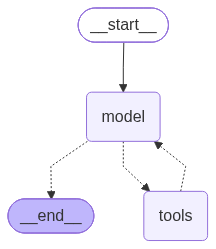

In [4]:
from langchain.agents import create_agent

agent = create_agent(
    model=model,
    tools=[tavily_search_tool, calc],
    system_prompt="You are a helpful assistant. Use tools when needed to answer questions."
)

agent

In [5]:
user_input = "What is the current AI news for anthropic and then calculate 5+5"

for step in agent.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current AI news for anthropic and then calculate 5+5
================================== Ai Message ==================================

I'll search for the latest AI news about Anthropic and calculate 5+5 in parallel.
Tool Calls:
  tavily_search (kanz8ddmw)
 Call ID: kanz8ddmw
  Args:
    exclude_domains: []
    include_domains: []
    include_images: False
    query: Anthropic AI latest news
    search_depth: None
    time_range: None
    topic: None
  calculator (0g114a5dh)
 Call ID: 0g114a5dh
  Args:
    expression: 5+5
================================= Tool Message =================================
Name: calculator

10
================================== Ai Message ==================================

## Current AI News: Anthropic

Here are the latest developments from Anthropic:

- **Claude Fable 5.1 and Mythos 5.1** — Anthropic has introduced what it describes as the world's most advanced m